## PChProp Version One: Data Exploration

In [1]:
""" Importing all required libraries """
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from pymongo import MongoClient


### Configuration

In [ ]:
# ====== CONFIG ======
MONGO_URI = "path/to/MongoDB"
DB_NAME = "opti_datacollection"
COLLECTION_NAME = "datacollection"

# Global trackers
rejection_count = 0

### Connection and Extraction

In [3]:
def parse_solubility_value(val):
    """Parses a single solubility value, handling strings, numbers, and boundary symbols."""
    if isinstance(val, (int, float)) and math.isfinite(val):
        return float(val)
    elif isinstance(val, str):
        v = val.replace(",", "").strip()
        if v.startswith("<") or v.startswith(">"):
            v = v[1:].strip()
        try:
            return float(v)
        except ValueError:
            return None
    return None

def extract_all_data():
    global rejection_count
    client = MongoClient(MONGO_URI)
    coll = client[DB_NAME][COLLECTION_NAME]
    
    # Projection to grab SMILES and the 4 required properties (LogP removed)
    cursor = coll.find({}, {
        "attributes.x_smiles": 1,
        "attributes.properties.x_solubility": 1,
        "attributes.properties.x_melting_point": 1,
        "attributes.properties.x_boiling_point": 1,
        "attributes.properties.x_henrys_law_constant": 1
    })

    data_with_meng = []
    data_without_meng = []
    
    # Overlap Counters for the Table
    counts = {
        "sol_only": 0,
        "sol_hlc": 0,
        "sol_mp": 0,
        "sol_bp": 0,
        "sol_all_four": 0
    }

    for doc in cursor:
        smiles = doc.get("attributes", {}).get("x_smiles")
        if not smiles: continue
            
        sol_list = doc.get("attributes", {}).get("properties", {}).get("x_solubility")
        if not isinstance(sol_list, list) or not sol_list: continue
            
        valid_with = []
        valid_without = []
        
        # Parse solubility and filter Meng2022
        for entry in sol_list:
            source = entry.get("provenance", {}).get("source", {}).get("name", "")
            val = parse_solubility_value(entry.get("value"))
            
            if val is not None:
                valid_with.append(val)
                if source != "Meng2022":
                    valid_without.append(val)
            else:
                rejection_count += 1
                
        # If we have valid solubility data
        if valid_with:
            data_with_meng.append({"SMILES": smiles, "LogS": np.mean(valid_with)})
            
            # --- Table Overlap Counting ---
            counts["sol_only"] += 1
            
            props = doc.get("attributes", {}).get("properties", {})
            has_hlc = bool(props.get("x_henrys_law_constant"))
            has_mp = bool(props.get("x_melting_point"))
            has_bp = bool(props.get("x_boiling_point"))
            
            if has_hlc: counts["sol_hlc"] += 1
            if has_mp: counts["sol_mp"] += 1
            if has_bp: counts["sol_bp"] += 1
            if has_hlc and has_mp and has_bp: 
                counts["sol_all_four"] += 1

        # If we have valid data AFTER removing Meng2022
        if valid_without:
            data_without_meng.append({"SMILES": smiles, "LogS": np.mean(valid_without)})

    df_with = pd.DataFrame(data_with_meng)
    df_without = pd.DataFrame(data_without_meng)
    
    return df_with, df_without, counts

# Execute Extraction
print("Connecting to MongoDB and extracting data...")
df_all, df_clean, overlap_counts = extract_all_data()
print("Extraction complete.")

Connecting to MongoDB and extracting data...
Extraction complete.


### Data Counts

In [4]:
print("====== DATA OVERLAP COUNTS  ======")
print(f"X_solubility: {overlap_counts['sol_only']}")
print(f"X_solubility ∩ X_HLC: {overlap_counts['sol_hlc']}")
print(f"X_solubility ∩ X_mp: {overlap_counts['sol_mp']}")
print(f"X_solubility ∩ X_bp: {overlap_counts['sol_bp']}")
print(f"X_solubility ∩ X_HLC ∩ X_mp ∩ X_bp: {overlap_counts['sol_all_four']}")
print("\n====== DATASET EXPORT METRICS ======")
print(f"Total entries after removing Meng2022: {len(df_clean)}")
print(f"Total invalid data points rejected: {rejection_count}")

====== DATA OVERLAP COUNTS  ======
X_solubility: 102927
X_solubility ∩ X_HLC: 790
X_solubility ∩ X_mp: 3343
X_solubility ∩ X_bp: 2160
X_solubility ∩ X_HLC ∩ X_mp ∩ X_bp: 524

====== DATASET EXPORT METRICS ======
Total entries after removing Meng2022: 1115
Total invalid data points rejected: 0


### Data Exporation for Featurisation

In [5]:
# Save the dataset strictly WITHOUT Meng2022 for downstream ML featurization
output_file = "solubility_data_no_meng2022.csv"
df_clean.to_csv(output_file, index=False)

print(f"Successfully saved {len(df_clean)} molecules to '{output_file}' for featurization.")

Successfully saved 1115 molecules to 'solubility_data_no_meng2022.csv' for featurization.


### Plotting Function

Distribution Plot: INCLUDING Meng2022


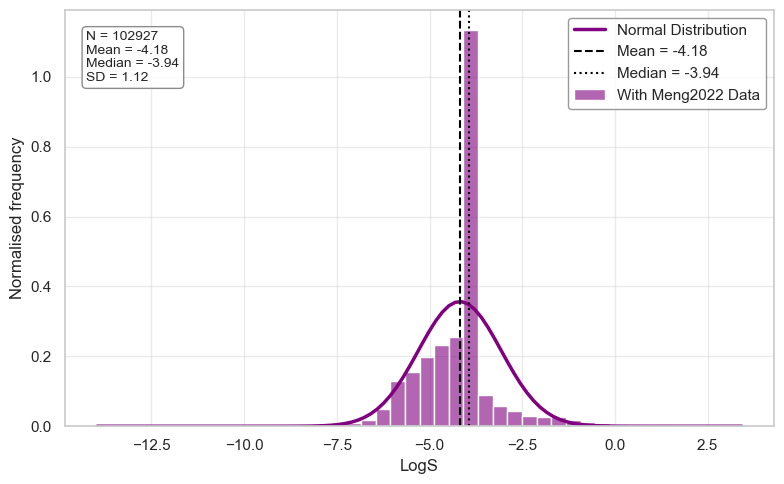

Distribution Plot: EXCLUDING Meng2022


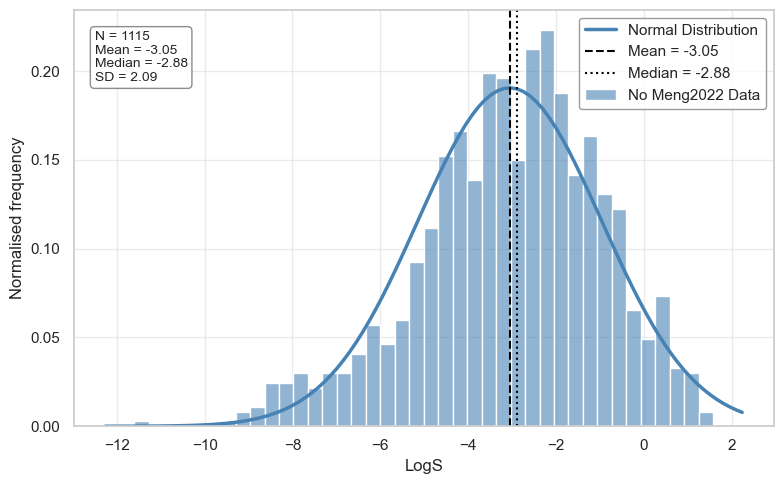

In [7]:
def plot_strict_distribution(series, color, label_prefix):
    """Plots LogS distribution with both a text box and a legend."""
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    
    # 1. Base Histogram (No KDE)
    sns.histplot(series, kde=False, stat='density', bins=40, color=color, alpha=0.6, label=f'{label_prefix} Data')
    
    mean_val = series.mean()
    median_val = series.median()
    std_val = series.std()
    
    # 2. Solid Normal Distribution Line
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean_val, std_val)
    plt.plot(x, p, color=color, linestyle='-', linewidth=2.5, label='Normal Distribution')
    
    # 3. Mean and Median Lines
    plt.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f"Mean = {mean_val:.2f}")
    plt.axvline(median_val, color='black', linestyle=':', linewidth=1.5, label=f"Median = {median_val:.2f}")

    # Formatting: Labels, Grid, No Title
    plt.xlabel("LogS")
    plt.ylabel("Normalised frequency")
    plt.grid(True, alpha=0.4)
    
    # 4. Custom Legend Box & Stats
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
    textstr = '\n'.join((
        f'N = {len(series)}',
        f'Mean = {mean_val:.2f}',
        f'Median = {median_val:.2f}',
        f'SD = {std_val:.2f}'
    ))
    
    # Place text box in the Top-Left corner
    plt.text(0.03, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', bbox=props)
    
    # Place the main legend in the Top-Right corner
    plt.legend(loc='upper right', frameon=True, edgecolor='gray', facecolor='white')
    
    plt.tight_layout()
    plt.show()

# Generate Purple plot (WITH Meng2022)
print("Distribution Plot: INCLUDING Meng2022")
plot_strict_distribution(df_all["LogS"], color="purple", label_prefix="With Meng2022")

# Generate Blue plot (WITHOUT Meng2022)
print("Distribution Plot: EXCLUDING Meng2022")
plot_strict_distribution(df_clean["LogS"], color="steelblue", label_prefix="No Meng2022")